In [19]:
import pyreadr
import numpy as np
import torch
from scipy.spatial.distance import cdist, pdist

from src.gmm import GMM
from src.flowgem import sample_flowgem

import numpy as np
import matplotlib.pyplot as plt

Load dataset.

In [12]:
datasets = ["parkinsons", "allergens", "concrete", "windspeed", "forest", "housing", "stock", "pumadyn32nm", "scm20d", "scm1d"]
#methods = ["flowgem", "mice", "gain", "hyperimpute", "miri", "bayes", "missdiff", "knewimp"]

In [13]:
Xstar_df = pyreadr.read_r(f"datasets/split_test/test.{datasets[0]}.RDS")[None]
X_miss_df = pyreadr.read_r(f"datasets/split_amputed/mar.{datasets[0]}.RDS")[None]

Energy distance.

In [14]:
def energy_distance(X, Y, scale):
    if scale:
        X_np = np.array(X)
        Y_np = np.array(Y)
        center = np.nanmean(X_np, axis=0)
        scl = np.nanstd(X_np, axis=0, ddof=1)

        X = (X_np - center) / scl

        # Scale imputed data using original data's mean and std
        Y = (Y_np - center) / scl

    XY = cdist(X, Y)
    XX = cdist(X, X)
    YY = cdist(Y, Y)
    return (2 * XY.mean() - XX.mean() - YY.mean()) * X.shape[0] / 2

def energy_distance_faster(X, Y, scale):
    if torch.max(torch.abs(X)).item() > 1e100 and torch.max(torch.abs(Y)).item() < 1e100:
        return torch.inf
    if scale:
        X_np = np.array(X)
        Y_np = np.array(Y)
        center = np.nanmean(X_np, axis=0)
        scl = np.nanstd(X_np, axis=0, ddof=1)

        X = (X_np - center) / scl

        # Scale imputed data using original data's mean and std
        Y = (Y_np - center) / scl

    n = X.shape[0]
    xx_mean = pdist(X).sum() * 2 / (n * n)   # divide by n^2 to match cdist mean
    yy_mean = pdist(Y).sum() * 2 / (n * n)   # same for Y
    xy_mean = cdist(X, Y).mean()

    return (2 * xy_mean - xx_mean - yy_mean) * n / 2

def energy_distance_fixed_X(X, XX_mean, Y):
    XY_mean = cdist(X, Y).mean()
    n = len(Y)
    YY_mean = pdist(Y).mean() * (n - 1) / n
    return 2 * XY_mean - XX_mean - YY_mean

Prepare the data.

In [23]:
Xm = torch.tensor(X_miss_df.values, dtype=torch.float64)
X = torch.nan_to_num(Xm, nan=0.0) # input to GMM

Xstar = torch.tensor(Xstar_df.values)

M_np = (X_miss_df.notna()).astype(int).values
M = torch.tensor(M_np, dtype=torch.float64)

In [22]:
cov_type = 'uni_diag'
n_k = 100
start = 10
step = 2
n_mc = 500
n_samples = X.shape[0]

gmm = GMM(X, M, cov_type)
mu, sigma, pi, kk, q, loglik, aic, bic = gmm.iterEM(n_k, start, step, n_mc, n_samples)

0 12.00 36400.20 -72310.40 -70844.04
1 14.00 40010.29 -79454.58 -77760.78
2 16.00 42229.05 -83816.09 -81894.86
3 18.00 43722.62 -86727.25 -84578.58
4 20.00 44775.91 -88757.83 -86381.73
5 22.00 46109.88 -91349.77 -88746.23
6 24.00 47188.28 -93430.55 -90599.58
7 26.00 47704.75 -94387.49 -91329.08
8 28.00 48015.97 -94933.94 -91648.09
9 30.00 48264.08 -95354.16 -91840.88
10 32.00 48498.90 -95747.80 -92007.08
11 34.00 48780.30 -96234.61 -92266.46
12 36.00 49048.15 -96694.30 -92498.71
13 38.00 49246.00 -97013.99 -92590.97
14 40.00 49390.11 -97226.22 -92575.76
15 42.00 49522.54 -97415.07 -92537.18
16 44.00 49671.18 -97636.35 -92531.02
17 46.00 49837.48 -97892.95 -92560.19
18 48.00 49976.81 -98095.62 -92535.43
19 50.00 50108.75 -98283.50 -92495.87
20 52.00 50215.59 -98421.17 -92406.10
21 54.00 50313.20 -98540.39 -92297.89
22 56.00 50418.41 -98674.81 -92204.87
23 58.00 50488.29 -98738.58 -92041.20
24 60.00 50609.79 -98905.59 -91980.77
25 62.00 50782.24 -99174.48 -92022.23
26 64.00 50917.13 -993

In [26]:
mu.shape

torch.Size([96, 18])

In [30]:
energy_distance_gmm = [energy_distance_faster(Xstar, gmm.sample_gmm(mu, sigma, pi, X.shape[0]), scale=False) for _ in range(500)]

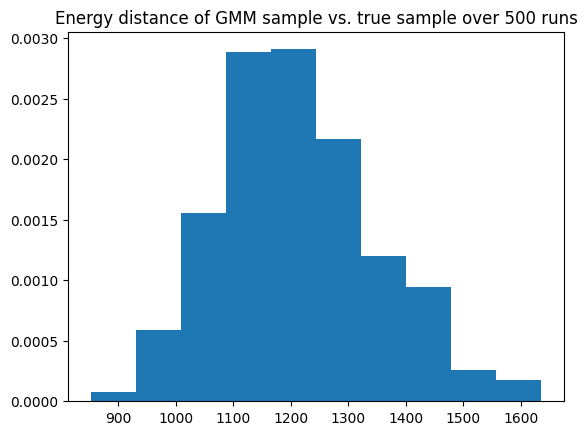

In [41]:
plt.hist(energy_distance_gmm, density=True)
plt.title('Energy distance of GMM sample vs. true sample over 500 runs')
plt.show()

In [36]:
Xhat_FG = sample_flowgem(X, X, M)

heuristic sigma: 4.334853825729436


WGF iterations:   0%|          | 2/1000 [00:01<15:52,  1.05it/s]

Step size eta is halved to 0.005 since mean grad has increased.


WGF iterations:   0%|          | 3/1000 [00:02<15:50,  1.05it/s]

Step size eta is halved to 0.0025 since mean grad has increased.


...

Step size eta is halved to 0.00125 since mean grad has increased.


WGF iterations:   2%|▎         | 25/1000 [00:24<16:02,  1.01it/s]

Step size eta is halved to 0.000625 since mean grad has increased.


WGF iterations:  43%|████▎     | 431/1000 [07:41<10:09,  1.07s/it]

Stopped early after 432 iterations since mean grad 0.0099 is below grad_tol=0.01.


In [39]:
energy_distance_faster(Xstar, Xhat_FG[-1], scale=False)

np.float64(7383.763010830448)